In [1]:
!python -m pip install medmnist


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np

dataset_dir = r"D:\Projet ML\DATA\ChestMNIST"

npz_files = [f for f in os.listdir(dataset_dir) if f.endswith(".npz")]
npz_files.sort()

print("Fichiers trouvés :")
for f in npz_files:
    full_path = os.path.join(dataset_dir, f)
    size_gb = os.path.getsize(full_path) / (1024**3)
    print(f"- {f} | {size_gb:.2f} Go")

print("\n--- Inspection d'un fichier ---")
sample_file = os.path.join(dataset_dir, npz_files[0])
print("Fichier inspecté :", sample_file)

data = np.load(sample_file)

print("\nClés contenues dans le fichier :")
for key in data.files:
    arr = data[key]
    print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")

Fichiers trouvés :
- chestmnist.npz | 0.08 Go
- chestmnist_128.npz | 1.33 Go
- chestmnist_224.npz | 3.62 Go
- chestmnist_64.npz | 0.37 Go

--- Inspection d'un fichier ---
Fichier inspecté : D:\Projet ML\DATA\ChestMNIST\chestmnist.npz

Clés contenues dans le fichier :
train_images: shape=(78468, 28, 28), dtype=uint8
val_images: shape=(11219, 28, 28), dtype=uint8
test_images: shape=(22433, 28, 28), dtype=uint8
train_labels: shape=(78468, 14), dtype=uint8
val_labels: shape=(11219, 14), dtype=uint8
test_labels: shape=(22433, 14), dtype=uint8



Dans ce projet, le jeu de données principal utilisé pour la classification supervisée est **ChestMNIST**, un sous-ensemble du projet **MedMNIST**, dédié aux radiographies thoraciques. Le dataset est fourni sous forme de fichiers `.npz` contenant directement les images et les labels déjà séparés en ensembles d’apprentissage, de validation et de test.

L’inspection initiale du dossier de données montre la présence de plusieurs versions du dataset selon la résolution des images :

- `chestmnist.npz` : images en **28 × 28**
- `chestmnist_64.npz` : images en **64 × 64**
- `chestmnist_128.npz` : images en **128 × 128**
- `chestmnist_224.npz` : images en **224 × 224**

Cette disponibilité en plusieurs résolutions est intéressante dans le cadre du projet, car elle permet d’adapter les expériences au coût de calcul et aux architectures utilisées. Les modèles simples pourront être entraînés sur des tailles réduites, tandis que les architectures plus avancées, comme les modèles pré-entraînés ou les Vision Transformers, pourront exploiter des résolutions plus élevées.

L’inspection du fichier `chestmnist.npz` montre la structure suivante :

- `train_images` : `(78468, 28, 28)`
- `val_images` : `(11219, 28, 28)`
- `test_images` : `(22433, 28, 28)`
- `train_labels` : `(78468, 14)`
- `val_labels` : `(11219, 14)`
- `test_labels` : `(22433, 14)`

Les images sont stockées en type `uint8`, ce qui indique qu’elles sont codées sous forme de niveaux de gris bruts. Les labels ont une dimension `(n, 14)`, ce qui montre que la tâche n’est pas une classification mono-classe classique, mais une **classification multilabel** : une même radiographie peut être associée à plusieurs pathologies simultanément.

La présence d’une séparation explicite entre apprentissage, validation et test constitue un point important pour garantir une évaluation rigoureuse et limiter les risques de fuite de données dans la suite du projet.

In [3]:
import os
import numpy as np
import pandas as pd


dataset_path = r"D:\Projet ML\DATA\ChestMNIST\chestmnist_128.npz"

data = np.load(dataset_path)

X_train = data["train_images"]
X_val = data["val_images"]
X_test = data["test_images"]

y_train = data["train_labels"]
y_val = data["val_labels"]
y_test = data["test_labels"]

print("=== Shapes ===")
print("X_train :", X_train.shape)
print("X_val   :", X_val.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_val   :", y_val.shape)
print("y_test  :", y_test.shape)

# =========================================================
# 2. Informations globales
# =========================================================
print("\n=== Infos globales ===")
print("Type images :", X_train.dtype)
print("Type labels :", y_train.dtype)
print("Valeur min pixel train :", X_train.min())
print("Valeur max pixel train :", X_train.max())

n_train = X_train.shape[0]
n_val = X_val.shape[0]
n_test = X_test.shape[0]
n_total = n_train + n_val + n_test

print("\nNombre total d'images :", n_total)
print(f"Train : {n_train} ({n_train / n_total:.2%})")
print(f"Val   : {n_val} ({n_val / n_total:.2%})")
print(f"Test  : {n_test} ({n_test / n_total:.2%})")

# =========================================================
# 3. Noms des 14 labels ChestMNIST
# =========================================================
label_names = [
    "Atelectasis",
    "Cardiomegaly",
    "Effusion",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax",
    "Consolidation",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Pleural_Thickening",
    "Hernia"
]

print("\nNombre de labels :", len(label_names))

# =========================================================
# 4. Fréquence de chaque label
# =========================================================
train_label_counts = y_train.sum(axis=0)
val_label_counts = y_val.sum(axis=0)
test_label_counts = y_test.sum(axis=0)

df_labels = pd.DataFrame({
    "label": label_names,
    "train_count": train_label_counts,
    "val_count": val_label_counts,
    "test_count": test_label_counts
})

df_labels["train_pct"] = df_labels["train_count"] / n_train * 100
df_labels["val_pct"] = df_labels["val_count"] / n_val * 100
df_labels["test_pct"] = df_labels["test_count"] / n_test * 100

print("\n=== Distribution des labels ===")
print(df_labels.sort_values("train_count", ascending=False).to_string(index=False))

# =========================================================
# 5. Nombre de labels positifs par image
# =========================================================
train_positive_per_image = y_train.sum(axis=1)
val_positive_per_image = y_val.sum(axis=1)
test_positive_per_image = y_test.sum(axis=1)

print("\n=== Nombre de labels positifs par image ===")
print("Train")
print(pd.Series(train_positive_per_image).value_counts().sort_index())

print("\nVal")
print(pd.Series(val_positive_per_image).value_counts().sort_index())

print("\nTest")
print(pd.Series(test_positive_per_image).value_counts().sort_index())

# =========================================================
# 6. Images sans aucune anomalie vs au moins une anomalie
# =========================================================
train_no_finding = np.sum(train_positive_per_image == 0)
val_no_finding = np.sum(val_positive_per_image == 0)
test_no_finding = np.sum(test_positive_per_image == 0)

print("\n=== Images sans label positif ===")
print(f"Train : {train_no_finding} ({train_no_finding / n_train:.2%})")
print(f"Val   : {val_no_finding} ({val_no_finding / n_val:.2%})")
print(f"Test  : {test_no_finding} ({test_no_finding / n_test:.2%})")

print("\n=== Images avec au moins un label positif ===")
print(f"Train : {n_train - train_no_finding} ({(n_train - train_no_finding) / n_train:.2%})")
print(f"Val   : {n_val - val_no_finding} ({(n_val - val_no_finding) / n_val:.2%})")
print(f"Test  : {n_test - test_no_finding} ({(n_test - test_no_finding) / n_test:.2%})")

=== Shapes ===
X_train : (78468, 128, 128)
X_val   : (11219, 128, 128)
X_test  : (22433, 128, 128)
y_train : (78468, 14)
y_val   : (11219, 14)
y_test  : (22433, 14)

=== Infos globales ===
Type images : uint8
Type labels : uint8
Valeur min pixel train : 0
Valeur max pixel train : 255

Nombre total d'images : 112120
Train : 78468 (69.99%)
Val   : 11219 (10.01%)
Test  : 22433 (20.01%)

Nombre de labels : 14

=== Distribution des labels ===
             label  train_count  val_count  test_count  train_pct   val_pct  test_pct
      Infiltration        13914       2018        3938  17.732069 17.987343 17.554496
          Effusion         9261       1292        2754  11.802263 11.516178 12.276557
       Atelectasis         7996       1119        2420  10.190141  9.974151 10.787679
            Nodule         4375        613        1335   5.575521  5.463945  5.951054
              Mass         3988        625        1133   5.082327  5.570906  5.050595
      Pneumothorax         3705        504

## Interprétation des premières statistiques globales sur ChestMNIST_128

Dans cette première étape d’analyse exploratoire, nous avons choisi de travailler avec le fichier **`chestmnist_128.npz`**. Ce choix correspond à un bon compromis entre qualité visuelle des radiographies et coût de calcul. En effet, une résolution de **128 × 128** permet de conserver davantage d’informations qu’en 28 × 28 ou 64 × 64, tout en restant plus abordable que la version 224 × 224 pour les temps d’entraînement et la mémoire GPU.

L’inspection du dataset montre que les données sont déjà séparées en trois sous-ensembles :

- **train** : 78 468 images
- **validation** : 11 219 images
- **test** : 22 433 images

Cela représente au total **112 120 radiographies**. La répartition est cohérente avec de bonnes pratiques de machine learning, avec environ **70 % pour l’apprentissage**, **10 % pour la validation** et **20 % pour le test**. Cette séparation préalable est très utile car elle facilite une évaluation rigoureuse du modèle et limite les risques de fuite de données entre les phases d’entraînement et de test. Cette logique est d’ailleurs conforme au cours, qui insiste sur l’importance de bien connaître les données avant la modélisation et de préparer un pipeline propre avec une séparation claire des jeux de données. :contentReference[oaicite:0]{index=0} :contentReference[oaicite:1]{index=1}


L’analyse des labels montre que la sortie a une forme **(n, 14)**. Cela confirme que nous sommes dans un problème de **classification multilabel** et non de classification simple à classe unique. Autrement dit, une même radiographie peut être associée à plusieurs pathologies thoraciques en même temps. Ce point a une conséquence directe sur la suite du projet : nous ne pourrons pas utiliser une logique de classification exclusive de type *une image = une seule classe*. Il faudra donc choisir des fonctions de perte, des métriques et des stratégies d’évaluation adaptées au multilabel.

Par ailleurs, les premiers résultats sur la distribution des labels montrent déjà un **déséquilibre de classes**. Par exemple, **Infiltration** apparaît dans environ **17,7 %** des images d’entraînement, alors que **Effusion** apparaît autour de **11,8 %**. Même si nous n’avons ici qu’un extrait du tableau complet, on observe déjà que certaines pathologies sont nettement plus fréquentes que d’autres. Ce point est très important, car un dataset déséquilibré peut biaiser l’apprentissage : un modèle peut être tenté de mieux prédire les classes fréquentes au détriment des classes rares. Cela justifie dès maintenant l’idée d’utiliser plus tard des métriques plus robustes que l’accuracy seule, comme le **F1-score**, le **ROC-AUC** ou encore le **PR-AUC**, comme demandé dans le sujet.

Un autre résultat important concerne la présence ou non d’anomalies dans les radiographies. Nous observons que :

- **45,96 %** des images d’entraînement ont **au moins un label positif**
- **45,82 %** des images de validation ont **au moins un label positif**
- **46,83 %** des images de test ont **au moins un label positif**

Cela signifie qu’environ **la moitié des images** contiennent au moins une pathologie annotée, tandis que l’autre moitié ne contient **aucun label positif**. Cette répartition est intéressante pour deux raisons. Premièrement, elle confirme que le dataset contient à la fois des cas pathologiques et des cas sans anomalie détectée, ce qui est pertinent pour un système d’aide au tri radiologique. Deuxièmement, cela pourra être utile pour la future composante de **détection d’anomalies par autoencodeur ou VAE**, puisque les images sans anomalie pourraient servir de référence pour apprendre une distribution “normale” et repérer des cas atypiques par erreur de reconstruction ou score latent.

Enfin, les proportions entre train, validation et test restent très proches non seulement en nombre d’images, mais aussi en proportion d’images positives. C’est un bon signe, car cela suggère une certaine cohérence statistique entre les différents sous-ensembles. En pratique, cela rendra les comparaisons de performances plus fiables lors de l’évaluation des modèles.

En résumé, cette première inspection permet déjà de dégager plusieurs constats essentiels :

1. le dataset est **volumineux** et bien séparé en train / validation / test ;
2. les images sont des **radiographies en niveaux de gris brutes**, qui devront être normalisées ;
3. le problème est un **problème multilabel à 14 pathologies** ;
4. les classes sont **déséquilibrées** ;
5. près de **la moitié des images** possèdent au moins une anomalie, ce qui est pertinent pour la classification comme pour la détection d’anomalies.

Ces observations constituent une base solide pour la suite de l’analyse exploratoire, qui devra maintenant approfondir la **distribution complète des classes**, visualiser des **exemples d’images**, et étudier les **co-occurrences entre labels**.

=== Labels officiels récupérés depuis MedMNIST ===
0: atelectasis
1: cardiomegaly
2: effusion
3: infiltration
4: mass
5: nodule
6: pneumonia
7: pneumothorax
8: consolidation
9: edema
10: emphysema
11: fibrosis
12: pleural
13: hernia

=== Distribution complète des labels (train) ===
        label  count  percentage
 infiltration  13914   17.732069
     effusion   9261   11.802263
  atelectasis   7996   10.190141
       nodule   4375    5.575521
         mass   3988    5.082327
 pneumothorax   3705    4.721670
consolidation   3263    4.158383
      pleural   2279    2.904369
 cardiomegaly   1950    2.485089
    emphysema   1799    2.292654
        edema   1690    2.153744
     fibrosis   1158    1.475761
    pneumonia    978    1.246368
       hernia    144    0.183514


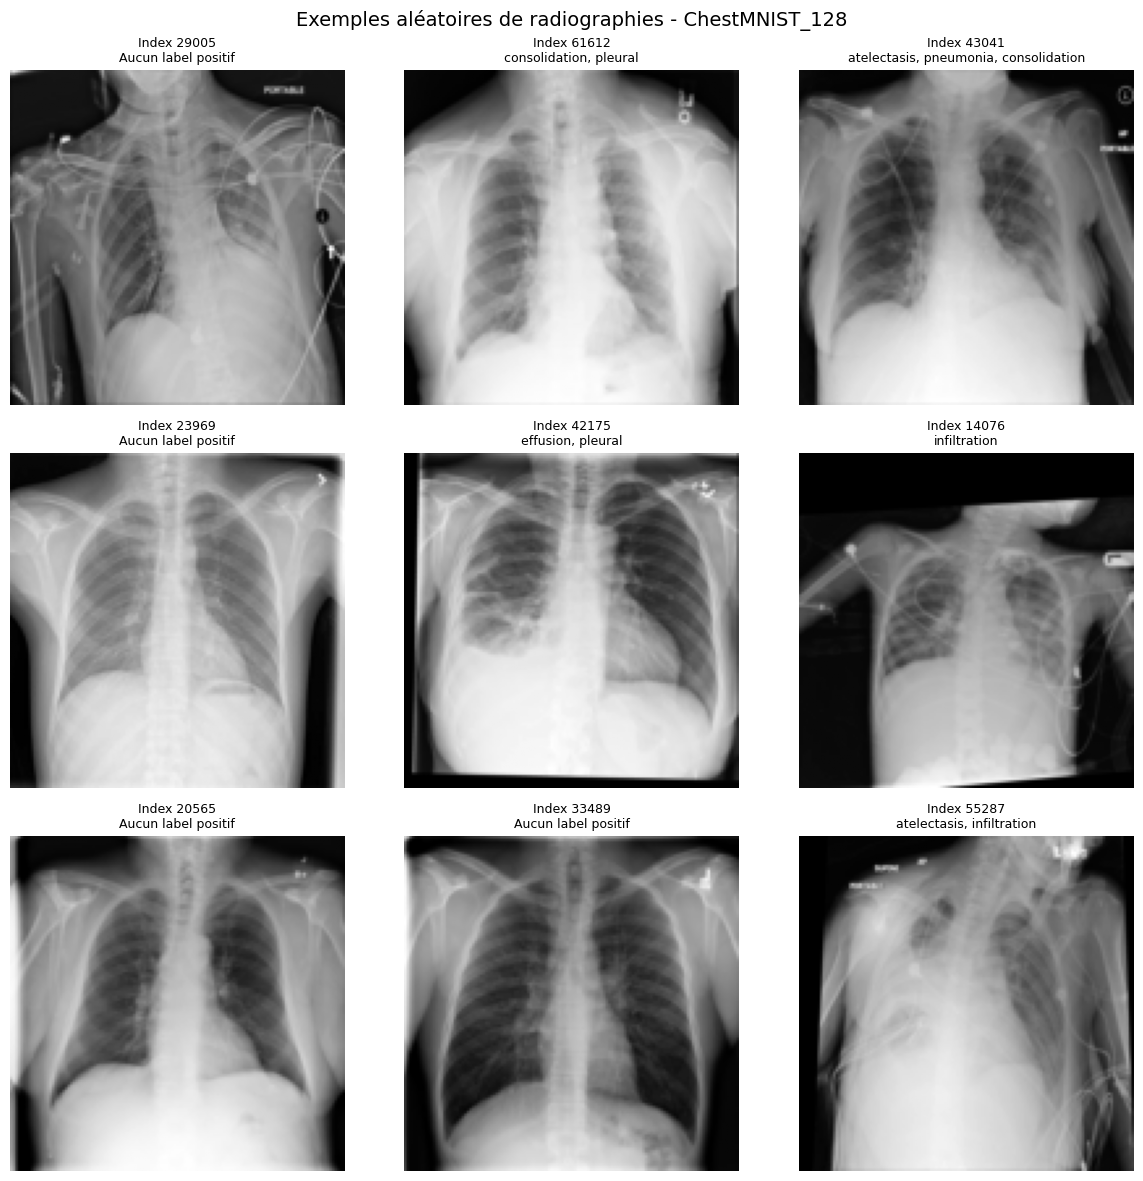

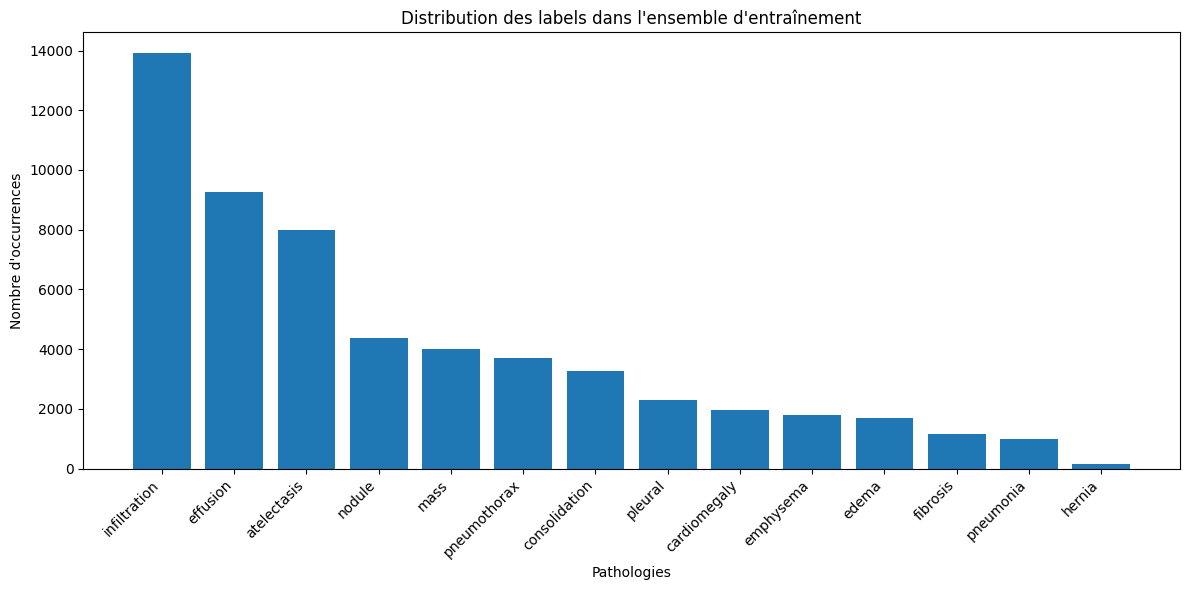


=== Mesure simple du déséquilibre ===
Classe la plus fréquente : infiltration - 13914
Classe la moins fréquente : hernia - 144
Rapport max/min : 96.62


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from medmnist import INFO

# Noms des labels depuis MedMNIST
info = INFO["chestmnist"]


if isinstance(info["label"], dict):
    label_names = [info["label"][str(i)] if str(i) in info["label"] else info["label"][i] for i in range(len(info["label"]))]
else:
    label_names = list(info["label"])

print("=== Labels officiels récupérés depuis MedMNIST ===")
for i, label in enumerate(label_names):
    print(f"{i}: {label}")


X_train = data["train_images"]
y_train = data["train_labels"]


train_counts = y_train.sum(axis=0)

df_labels = pd.DataFrame({
    "label": label_names,
    "count": train_counts
})

df_labels["percentage"] = df_labels["count"] / len(y_train) * 100
df_labels = df_labels.sort_values("count", ascending=False)

print("\n=== Distribution complète des labels (train) ===")
print(df_labels.to_string(index=False))


np.random.seed(42)
sample_indices = np.random.choice(len(X_train), size=9, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle("Exemples aléatoires de radiographies - ChestMNIST_128", fontsize=14)

for ax, idx in zip(axes.ravel(), sample_indices):
    image = X_train[idx]
    labels = y_train[idx]

    positive_labels = [label_names[i] for i, v in enumerate(labels) if v == 1]
    if len(positive_labels) == 0:
        label_text = "Aucun label positif"
    else:
        label_text = ", ".join(positive_labels[:3])
        if len(positive_labels) > 3:
            label_text += " ..."

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Index {idx}\n{label_text}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
plt.bar(df_labels["label"], df_labels["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Distribution des labels dans l'ensemble d'entraînement")
plt.xlabel("Pathologies")
plt.ylabel("Nombre d'occurrences")
plt.tight_layout()
plt.show()


max_count = df_labels["count"].max()
min_count = df_labels["count"].min()

print("\n=== Mesure simple du déséquilibre ===")
print("Classe la plus fréquente :", df_labels.iloc[0]["label"], "-", int(max_count))
print("Classe la moins fréquente :", df_labels.iloc[-1]["label"], "-", int(min_count))

if min_count > 0:
    print("Rapport max/min :", round(max_count / min_count, 2))
else:
    print("Rapport max/min : impossible à calculer car une classe a 0 occurrence")

## Interprétation des exemples visuels et de la distribution des classes

Cette étape d’analyse exploratoire permet d’aller au-delà des statistiques globales et de mieux comprendre la nature concrète des données contenues dans **ChestMNIST_128**.

### 1. Observation visuelle des radiographies

L’affichage d’un échantillon aléatoire de radiographies montre que les images correspondent bien à des **radiographies thoraciques en niveaux de gris**, avec des variations visibles de contraste, de cadrage et de qualité. Certaines images paraissent relativement nettes et centrées, tandis que d’autres présentent un cadrage moins homogène, des marqueurs, ou encore des artefacts liés à l’acquisition. Cela montre que le modèle devra apprendre sur des données qui ne sont pas parfaitement uniformes, ce qui est représentatif d’un contexte médical réel.

On observe également que certaines radiographies sont annotées avec **aucun label positif**, alors que d’autres présentent **plusieurs pathologies simultanément**. Par exemple, certaines images de l’échantillon affichent des combinaisons comme *atelectasis + pneumonia + consolidation* ou encore *atelectasis + infiltration*. Cela confirme visuellement que le problème est bien un **problème multilabel**, dans lequel une même image peut relever de plusieurs catégories en même temps.

Cette caractéristique a une conséquence importante pour la suite du projet : le modèle supervisé ne devra pas choisir une seule classe parmi 14, mais produire un **vecteur de probabilités indépendantes**, avec une décision par pathologie.

### 2. Distribution des classes

Le graphique de distribution des labels met clairement en évidence un **fort déséquilibre entre les pathologies**.

Les classes les plus fréquentes dans l’ensemble d’entraînement sont :

- **infiltration** : 13 914 cas (**17,73 %**)
- **effusion** : 9 261 cas (**11,80 %**)
- **atelectasis** : 7 996 cas (**10,19 %**)

À l’inverse, certaines pathologies sont beaucoup plus rares :

- **fibrosis** : 1 158 cas (**1,48 %**)
- **pneumonia** : 978 cas (**1,25 %**)
- **hernia** : 144 cas (**0,18 %**)

Le cas de **hernia** est particulièrement important : cette classe est extrêmement minoritaire par rapport aux autres. Le rapport entre la classe la plus fréquente (**infiltration**) et la plus rare (**hernia**) est de **96,62**. Cela signifie que la pathologie la plus représentée apparaît presque **97 fois plus souvent** que la moins représentée.

### 3. Interprétation du déséquilibre

Ce déséquilibre constitue un enjeu central pour la modélisation. En effet, si l’on utilise une approche naïve, le modèle risque d’apprendre plus facilement à reconnaître les classes fréquentes et à négliger les classes rares. Dans un contexte médical, ce serait problématique, car certaines pathologies peu fréquentes peuvent être cliniquement importantes.

Cela justifie plusieurs choix méthodologiques pour la suite :

- ne pas utiliser l’**accuracy** comme métrique principale ;
- privilégier des métriques plus adaptées comme le **F1-score**, le **ROC-AUC** et éventuellement le **PR-AUC** ;
- envisager des méthodes de gestion du déséquilibre, comme une **pondération de la loss**, un **échantillonnage adapté**, ou une interprétation prudente des résultats par classe.

### 4. Conséquences pour la suite du projet

Ces résultats confirment que le dataset est pertinent pour le sujet, mais aussi qu’il présente des difficultés réalistes :

- hétérogénéité visuelle des radiographies ;
- présence d’images normales et pathologiques ;
- coexistence de plusieurs pathologies sur une même image ;
- fort déséquilibre entre les labels.

Cette analyse est essentielle, car elle guide directement les prochaines étapes du pipeline : la préparation des données, le choix des fonctions de perte, les métriques d’évaluation et l’analyse par classe devront tenir compte de cette structure multilabel déséquilibrée.

y_train shape : (78468, 14)
Nombre de labels : 14
Type initial y_train : uint8
Type converti y_train_int : int32

=== Matrice correcte de co-occurrence ===
               atelectasis  cardiomegaly  effusion  infiltration  mass  \
atelectasis           7996           264      2226          2281   503   
cardiomegaly           264          1950       741           431    75   
effusion              2226           741      9261          2801   865   
infiltration          2281           431      2801         13914   822   
mass                   503            75       865           822  3988   
nodule                 405            80       645          1057   605   
pneumonia              188            21       195           414    42   
pneumothorax           522            32       711           662   291   
consolidation          813           126       896           841   435   
edema                  163            85       437           726    90   
emphysema              316    

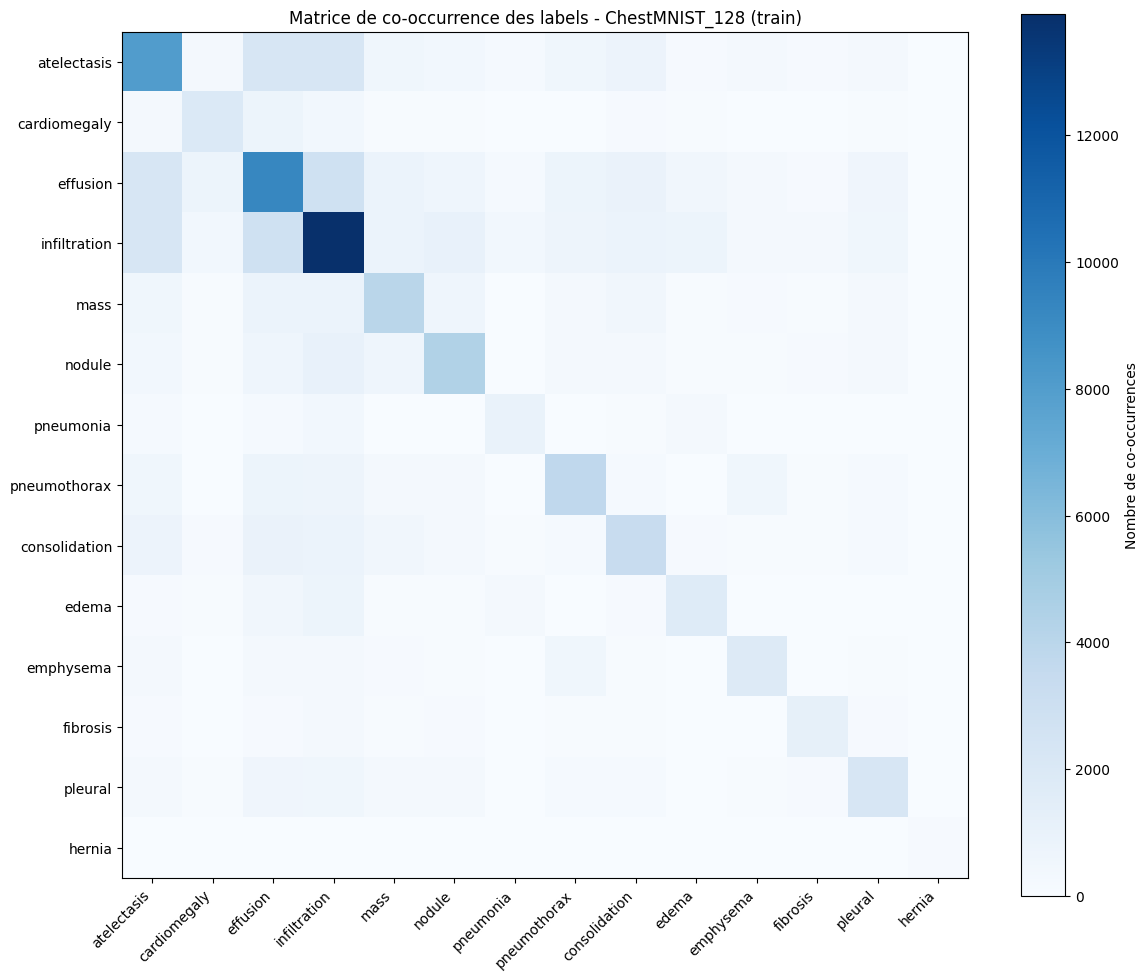


=== Matrice de corrélation des labels ===
               atelectasis  cardiomegaly  effusion  infiltration   mass  \
atelectasis          1.000         0.018     0.167         0.095  0.019   
cardiomegaly         0.018         1.000     0.130         0.018 -0.009   
effusion             0.167         0.130     1.000         0.120  0.071   
infiltration         0.095         0.018     0.120         1.000  0.017   
mass                 0.019        -0.009     0.071         0.017  1.000   
nodule              -0.007        -0.010     0.022         0.041  0.097   
pneumonia            0.034        -0.002     0.028         0.072 -0.004   
pneumothorax         0.029        -0.023     0.051         0.001  0.028   
consolidation        0.101         0.018     0.101         0.044  0.078   
edema               -0.003         0.024     0.065         0.098  0.002   
emphysema            0.037        -0.004     0.014        -0.001  0.019   
fibrosis             0.015         0.010    -0.003       

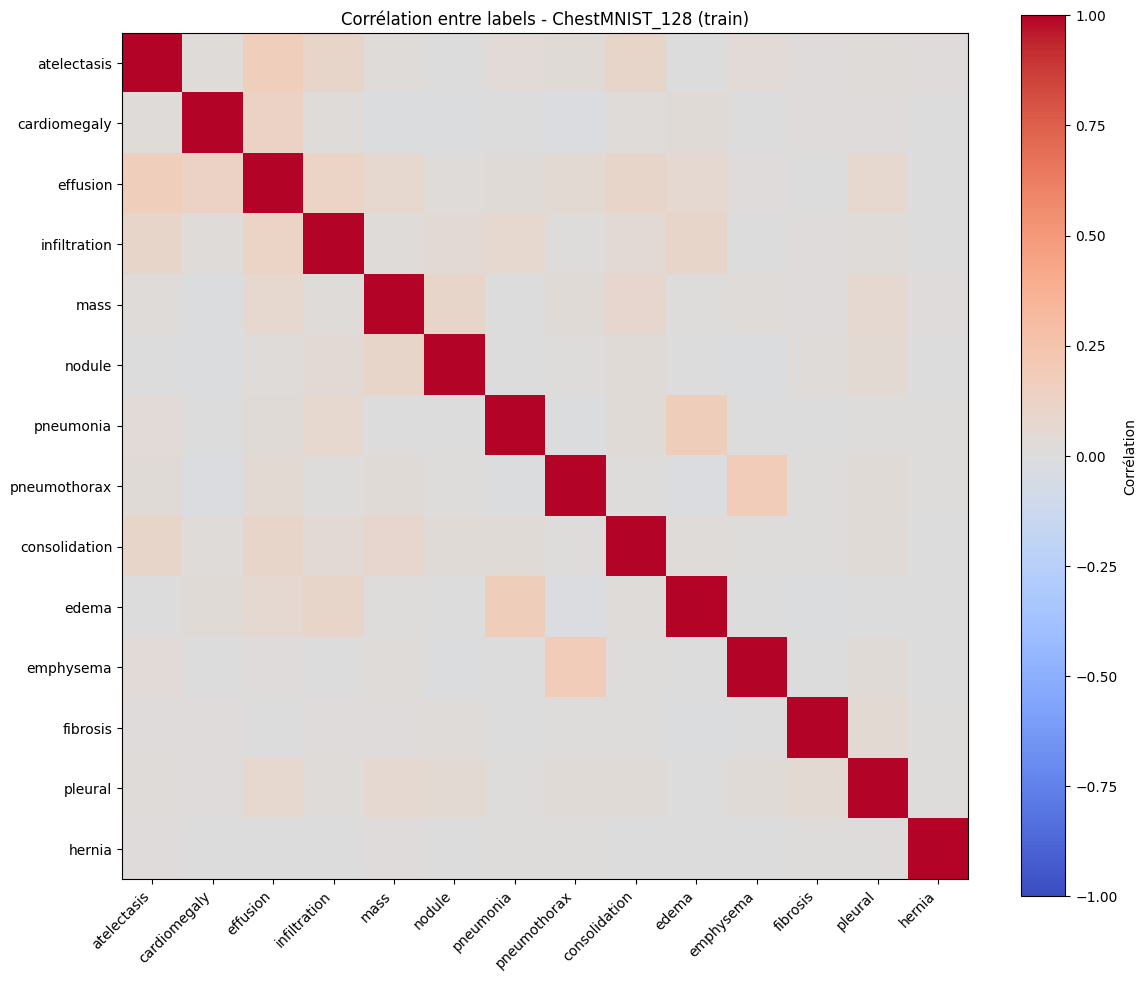


=== Top 20 des corrélations positives entre labels ===
     label_1       label_2  correlation
pneumothorax     emphysema     0.182280
   pneumonia         edema     0.177991
 atelectasis      effusion     0.167429
cardiomegaly      effusion     0.129625
    effusion  infiltration     0.119846
 atelectasis consolidation     0.101392
    effusion consolidation     0.101085
infiltration         edema     0.097991
        mass        nodule     0.096765
 atelectasis  infiltration     0.095201
        mass consolidation     0.078231
    effusion       pleural     0.076452
infiltration     pneumonia     0.072356
    effusion          mass     0.070916
        mass       pleural     0.065709
    effusion         edema     0.064635
    effusion  pneumothorax     0.050976
    fibrosis       pleural     0.049951
      nodule       pleural     0.048598
infiltration consolidation     0.043857


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("y_train shape :", y_train.shape)
print("Nombre de labels :", len(label_names))
print("Type initial y_train :", y_train.dtype)

# Conversion pour éviter l'overflow sur les co-occurrences
y_train_int = y_train.astype(np.int32)

print("Type converti y_train_int :", y_train_int.dtype)

# Matrice de co-occurrence correcte
cooc_matrix = y_train_int.T @ y_train_int

cooc_df = pd.DataFrame(cooc_matrix, index=label_names, columns=label_names)

print("\n=== Matrice correcte de co-occurrence ===")
print(cooc_df)

true_counts = y_train_int.sum(axis=0)

check_df = pd.DataFrame({
    "label": label_names,
    "diag_cooc": np.diag(cooc_matrix),
    "true_count": true_counts
})

check_df["match"] = check_df["diag_cooc"] == check_df["true_count"]

print("\n=== Vérification diagonale vs effectifs réels ===")
print(check_df.to_string(index=False))

# Top 20 des co-occurrences entre labels
pairs = []

for i in range(len(label_names)):
    for j in range(i + 1, len(label_names)):
        pairs.append({
            "label_1": label_names[i],
            "label_2": label_names[j],
            "cooccurrence_count": int(cooc_matrix[i, j])
        })

pairs_df = pd.DataFrame(pairs).sort_values("cooccurrence_count", ascending=False)

print("\n=== Top 20 des co-occurrences entre labels ===")
print(pairs_df.head(20).to_string(index=False))

# Heatmap de la matrice de co-occurrence
plt.figure(figsize=(12, 10))
plt.imshow(cooc_matrix, cmap="Blues")
plt.colorbar(label="Nombre de co-occurrences")
plt.xticks(ticks=np.arange(len(label_names)), labels=label_names, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(label_names)), labels=label_names)
plt.title("Matrice de co-occurrence des labels - ChestMNIST_128 (train)")
plt.tight_layout()
plt.show()

# Corrélation entre labels
y_train_df = pd.DataFrame(y_train_int, columns=label_names)
corr_df = y_train_df.corr()

print("\n=== Matrice de corrélation des labels ===")
print(corr_df.round(3))

plt.figure(figsize=(12, 10))
plt.imshow(corr_df, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Corrélation")
plt.xticks(ticks=np.arange(len(label_names)), labels=label_names, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(label_names)), labels=label_names)
plt.title("Corrélation entre labels - ChestMNIST_128 (train)")
plt.tight_layout()
plt.show()

# Top 20 des corrélations positives entre labels
corr_pairs = []

for i in range(len(label_names)):
    for j in range(i + 1, len(label_names)):
        corr_pairs.append({
            "label_1": label_names[i],
            "label_2": label_names[j],
            "correlation": corr_df.iloc[i, j]
        })

corr_pairs_df = pd.DataFrame(corr_pairs).sort_values("correlation", ascending=False)

print("\n=== Top 20 des corrélations positives entre labels ===")
print(corr_pairs_df.head(20).to_string(index=False))

## Interprétation des co-occurrences et corrélations entre labels

Après correction du calcul de co-occurrence en convertissant les labels en `int32`, la matrice obtenue devient cohérente. La diagonale correspond bien au nombre réel d’occurrences de chaque classe, ce qui confirme que les comptages sont désormais fiables.

### 1. Co-occurrences entre pathologies

L’analyse des co-occurrences montre que certaines pathologies apparaissent fréquemment ensemble dans les radiographies thoraciques. Parmi les associations les plus marquées en nombre absolu, on retrouve notamment :

- `effusion` – `infiltration`
- `atelectasis` – `infiltration`
- `atelectasis` – `effusion`
- `effusion` – `consolidation`
- `atelectasis` – `consolidation`
- `pneumothorax` – `emphysema`

Ces résultats indiquent que les pathologies thoraciques ne sont pas distribuées de manière indépendante dans le dataset. Certaines anomalies ont tendance à coexister dans une même image, ce qui renforce la difficulté du problème multilabel : le modèle devra apprendre non seulement à reconnaître chaque pathologie individuellement, mais aussi à gérer des combinaisons fréquentes de diagnostics.

### 2. Corrélations entre labels

La matrice de corrélation confirme cette idée, mais montre que les relations restent globalement **modérées** plutôt que très fortes. Les corrélations positives les plus élevées observées sont :

- `pneumothorax` – `emphysema` : **0,182**
- `pneumonia` – `edema` : **0,178**
- `atelectasis` – `effusion` : **0,167**
- `cardiomegaly` – `effusion` : **0,130**
- `effusion` – `infiltration` : **0,120**

Ces valeurs restent relativement faibles en absolu, ce qui signifie que même si certaines pathologies coexistent plus souvent que d’autres, il n’existe pas de dépendance très forte entre la majorité des labels. En d’autres termes, les associations existent, mais elles ne sont ni systématiques ni suffisantes pour prédire une pathologie uniquement à partir d’une autre.

### 3. Lecture métier / médicale

Plusieurs couples observés semblent plausibles d’un point de vue radiologique. Par exemple :

- `atelectasis` et `effusion`
- `cardiomegaly` et `effusion`
- `mass` et `nodule`
- `pneumothorax` et `emphysema`

Même sans expertise clinique avancée, ces regroupements suggèrent que le dataset capture des relations médicalement crédibles entre anomalies thoraciques. Cela est intéressant pour le projet, car le modèle devra évoluer dans un contexte réaliste où plusieurs signes peuvent apparaître simultanément.

### 4. Conséquences pour la modélisation

Cette analyse a plusieurs implications importantes pour la suite :

- le problème doit bien être traité comme une **classification multilabel** ;
- l’évaluation devra être faite **par classe** et non seulement de manière globale ;
- certaines erreurs du modèle pourront être liées à des pathologies visuellement proches ou fréquemment associées ;
- la stratégie d’apprentissage devra tenir compte à la fois du **déséquilibre des classes** et des **co-occurrences entre labels**.

### 5. Conclusion de l’EDA sur ChestMNIST

À ce stade, l’analyse exploratoire du dataset ChestMNIST_128 permet de dégager plusieurs constats majeurs :

- le dataset est volumineux et correctement séparé en train / validation / test ;
- les images sont des radiographies thoraciques en niveaux de gris brutes ;
- la tâche est une **classification multilabel à 14 pathologies** ;
- les classes sont fortement déséquilibrées ;
- certaines pathologies ont tendance à apparaître ensemble ;
- le dataset est donc réaliste, mais également complexe à modéliser.

Ces constats justifient la mise en place d’une étape de préparation des données rigoureuse avant d’entraîner les modèles supervisés.